<a href="https://colab.research.google.com/github/rjacaac/TSR_detection/blob/main/tsd_yolov10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Sign Detection Using YOLOv10

## Installing Necessary Libraries

In [1]:
!pip install -q roboflow
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 872.2/872.2 kB 30.5 MB/s eta 0:00:00


In [2]:
!nvidia-smi

Sat Aug 31 13:08:47 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:00:04.0 Off |                    0 |
| N/A   32C    P0              48W / 400W |      2MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Importing Necessary Libraries

In [4]:
import glob
import ultralytics
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image
from roboflow import Roboflow
from ultralytics import YOLO
ultralytics.checks()

Ultralytics YOLOv8.2.84 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 32.8/201.2 GB disk)


## Downloading the Dataset from Roboflow

In [5]:
rf = Roboflow(api_key="S1UXwOO14zABClWuufoa")
project = rf.workspace("my-workspace-ozcmx").project("traffic-sign-detection-vnb4u")
version = project.version(16)
dataset = version.download("yolov9")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Sign-Detection-16 in yolov9:: 100%|██████████| 40012/40012 [00:05<00:00, 6744.95it/s]


## Model Training

In [6]:
%cd {HOME}

!yolo task=detect mode=train batch=128 imgsz=640 epochs=300 patience=50 \
save=True cache=True plots=True \
model=yolov10n.pt \
data={dataset.location}/data.yaml \
name='tsd_model_8'

/content
100% 5.59M/5.59M [00:00<00:00, 362MB/s]
Ultralytics YOLOv8.2.84 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
engine/trainer: task=detect, mode=train, model=yolov10n.pt, data=/content/Traffic-Sign-Detection-16/data.yaml, epochs=300, time=None, patience=50, batch=128, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=tsd_model_8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, sa

## Model Evaluation

### View Files of the Training Run

In [7]:
!ls {HOME}/runs/detect/tsd_model_8/

args.yaml					    R_curve.png		  val_batch0_labels.jpg
confusion_matrix_normalized.png			    results.csv		  val_batch0_pred.jpg
confusion_matrix.png				    results.png		  val_batch1_labels.jpg
events.out.tfevents.1725109975.0182fb8fd683.4531.0  train_batch0.jpg	  val_batch1_pred.jpg
F1_curve.png					    train_batch1.jpg	  val_batch2_labels.jpg
labels_correlogram.jpg				    train_batch2.jpg	  val_batch2_pred.jpg
labels.jpg					    train_batch34220.jpg  weights
P_curve.png					    train_batch34221.jpg
PR_curve.png					    train_batch34222.jpg


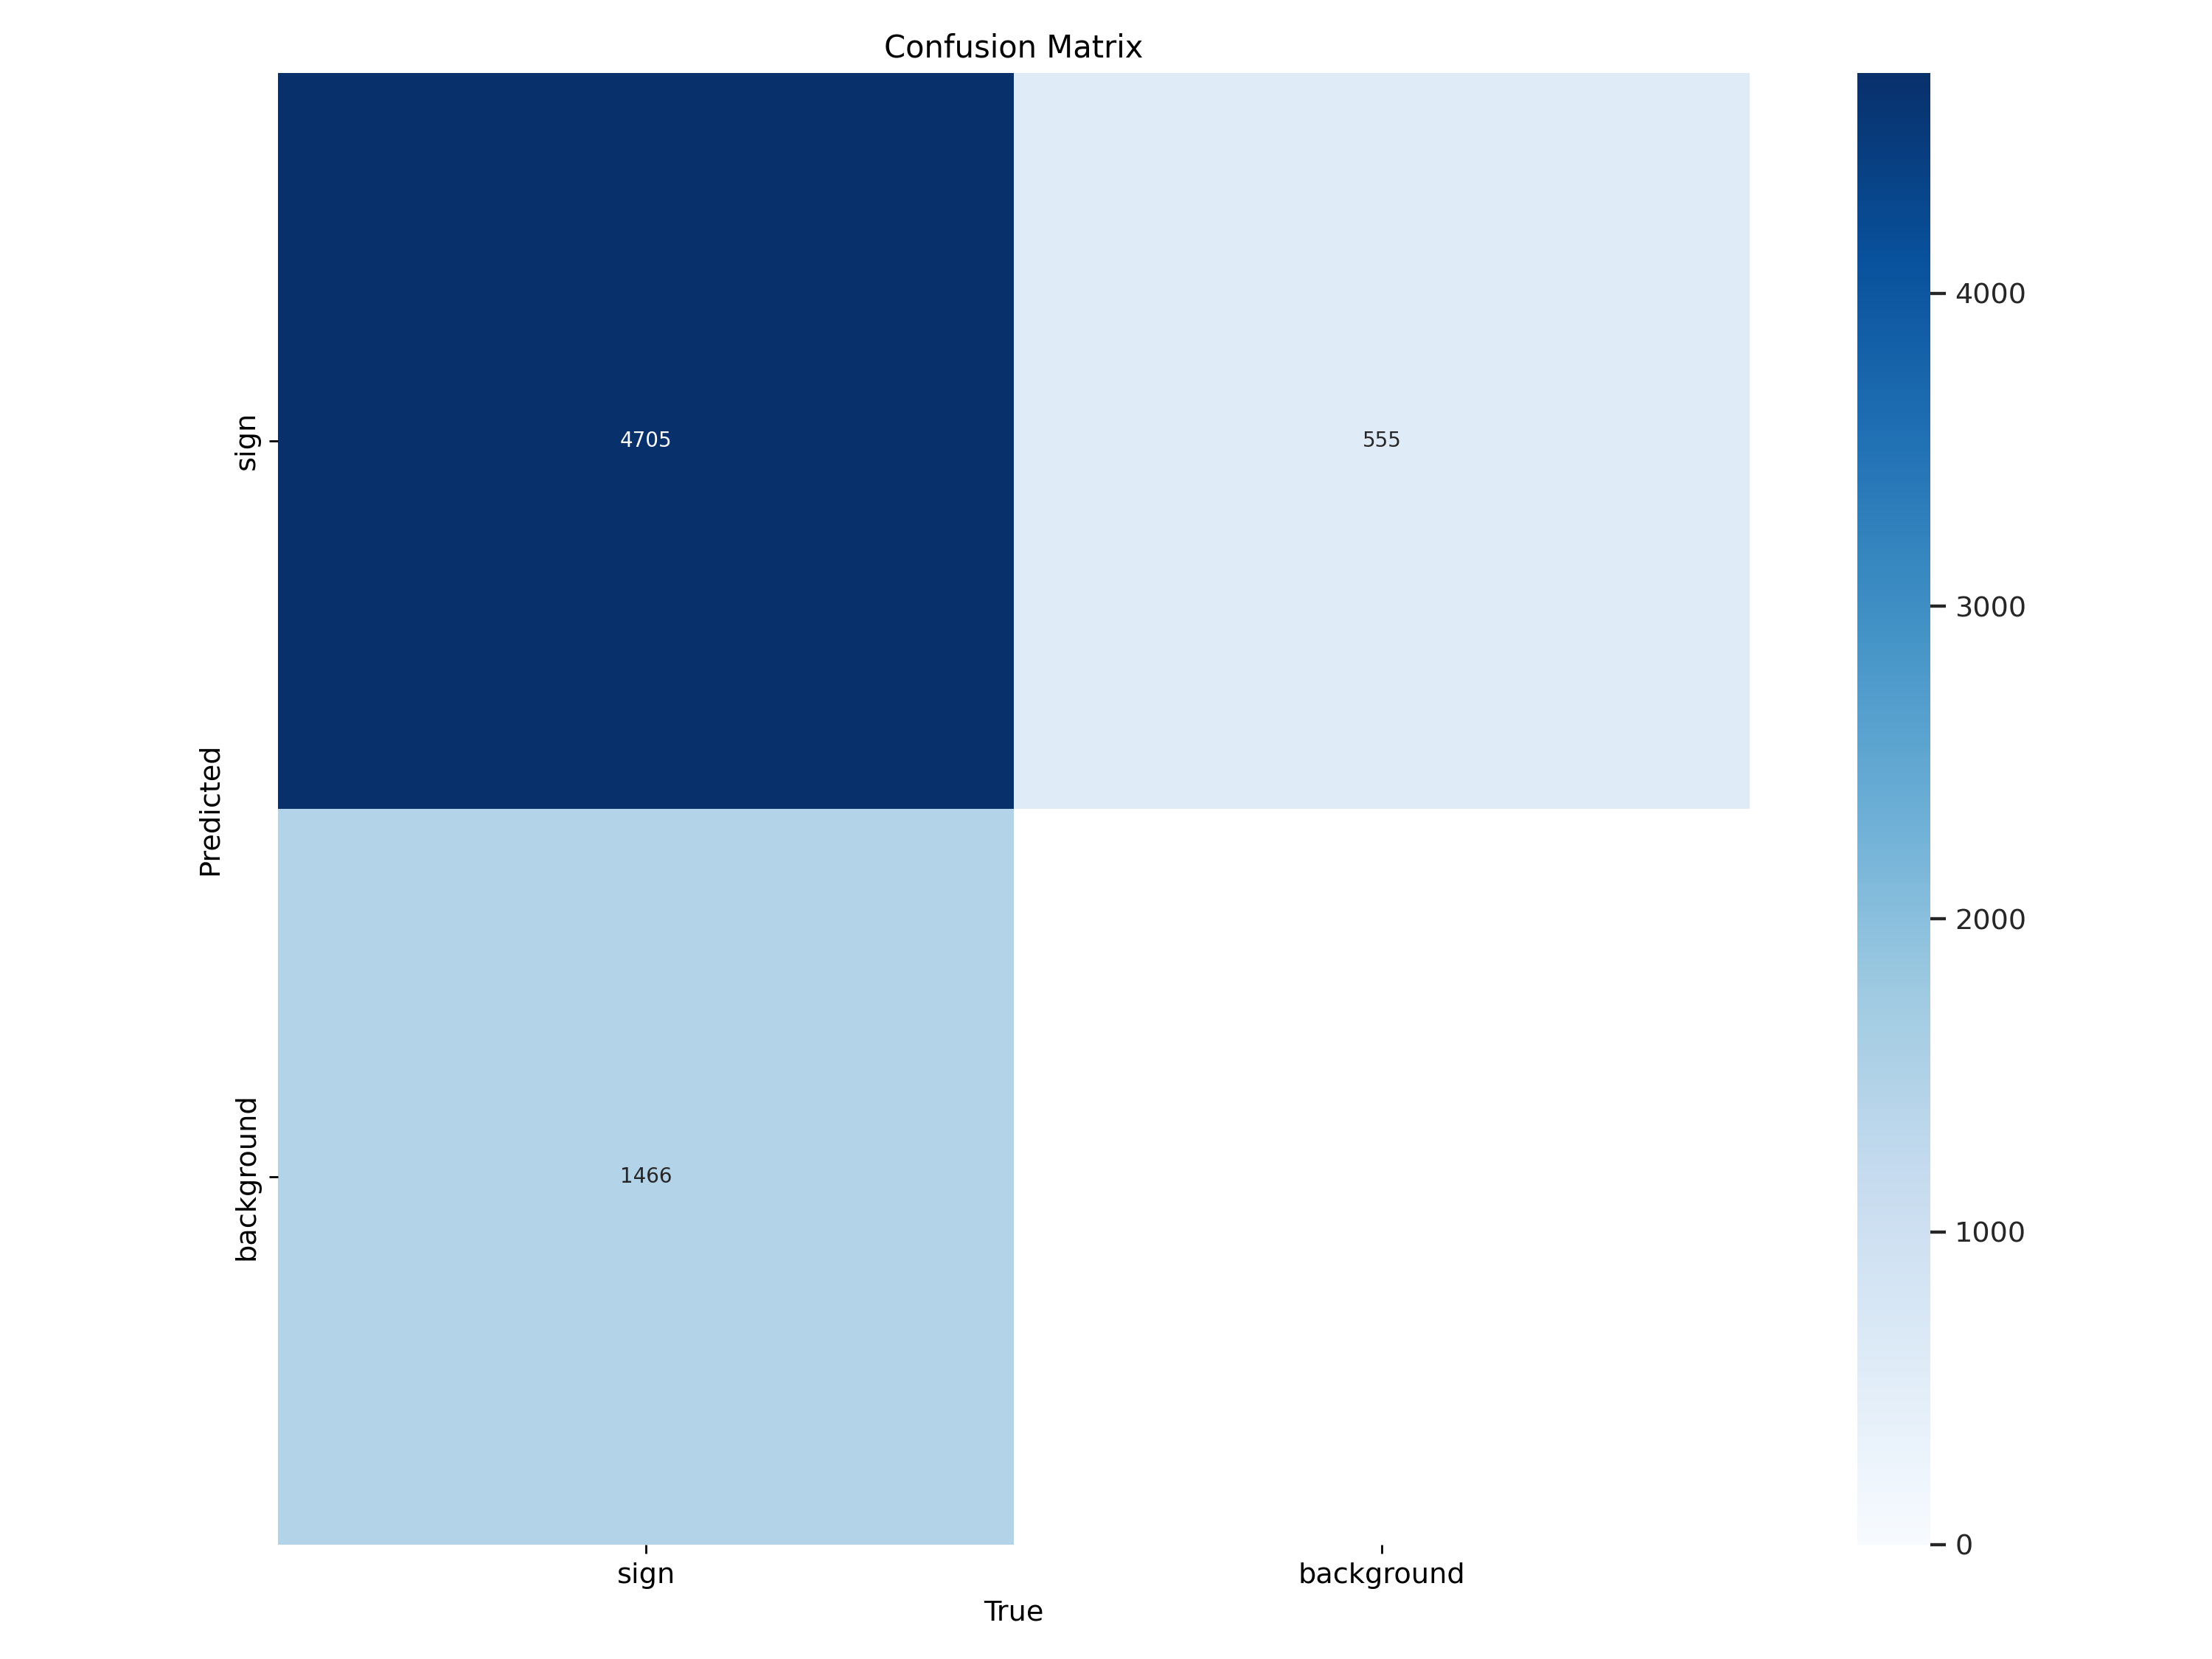

In [18]:
Image(filename=f'{HOME}/runs/detect/tsd_model_8/confusion_matrix.png', width=800)

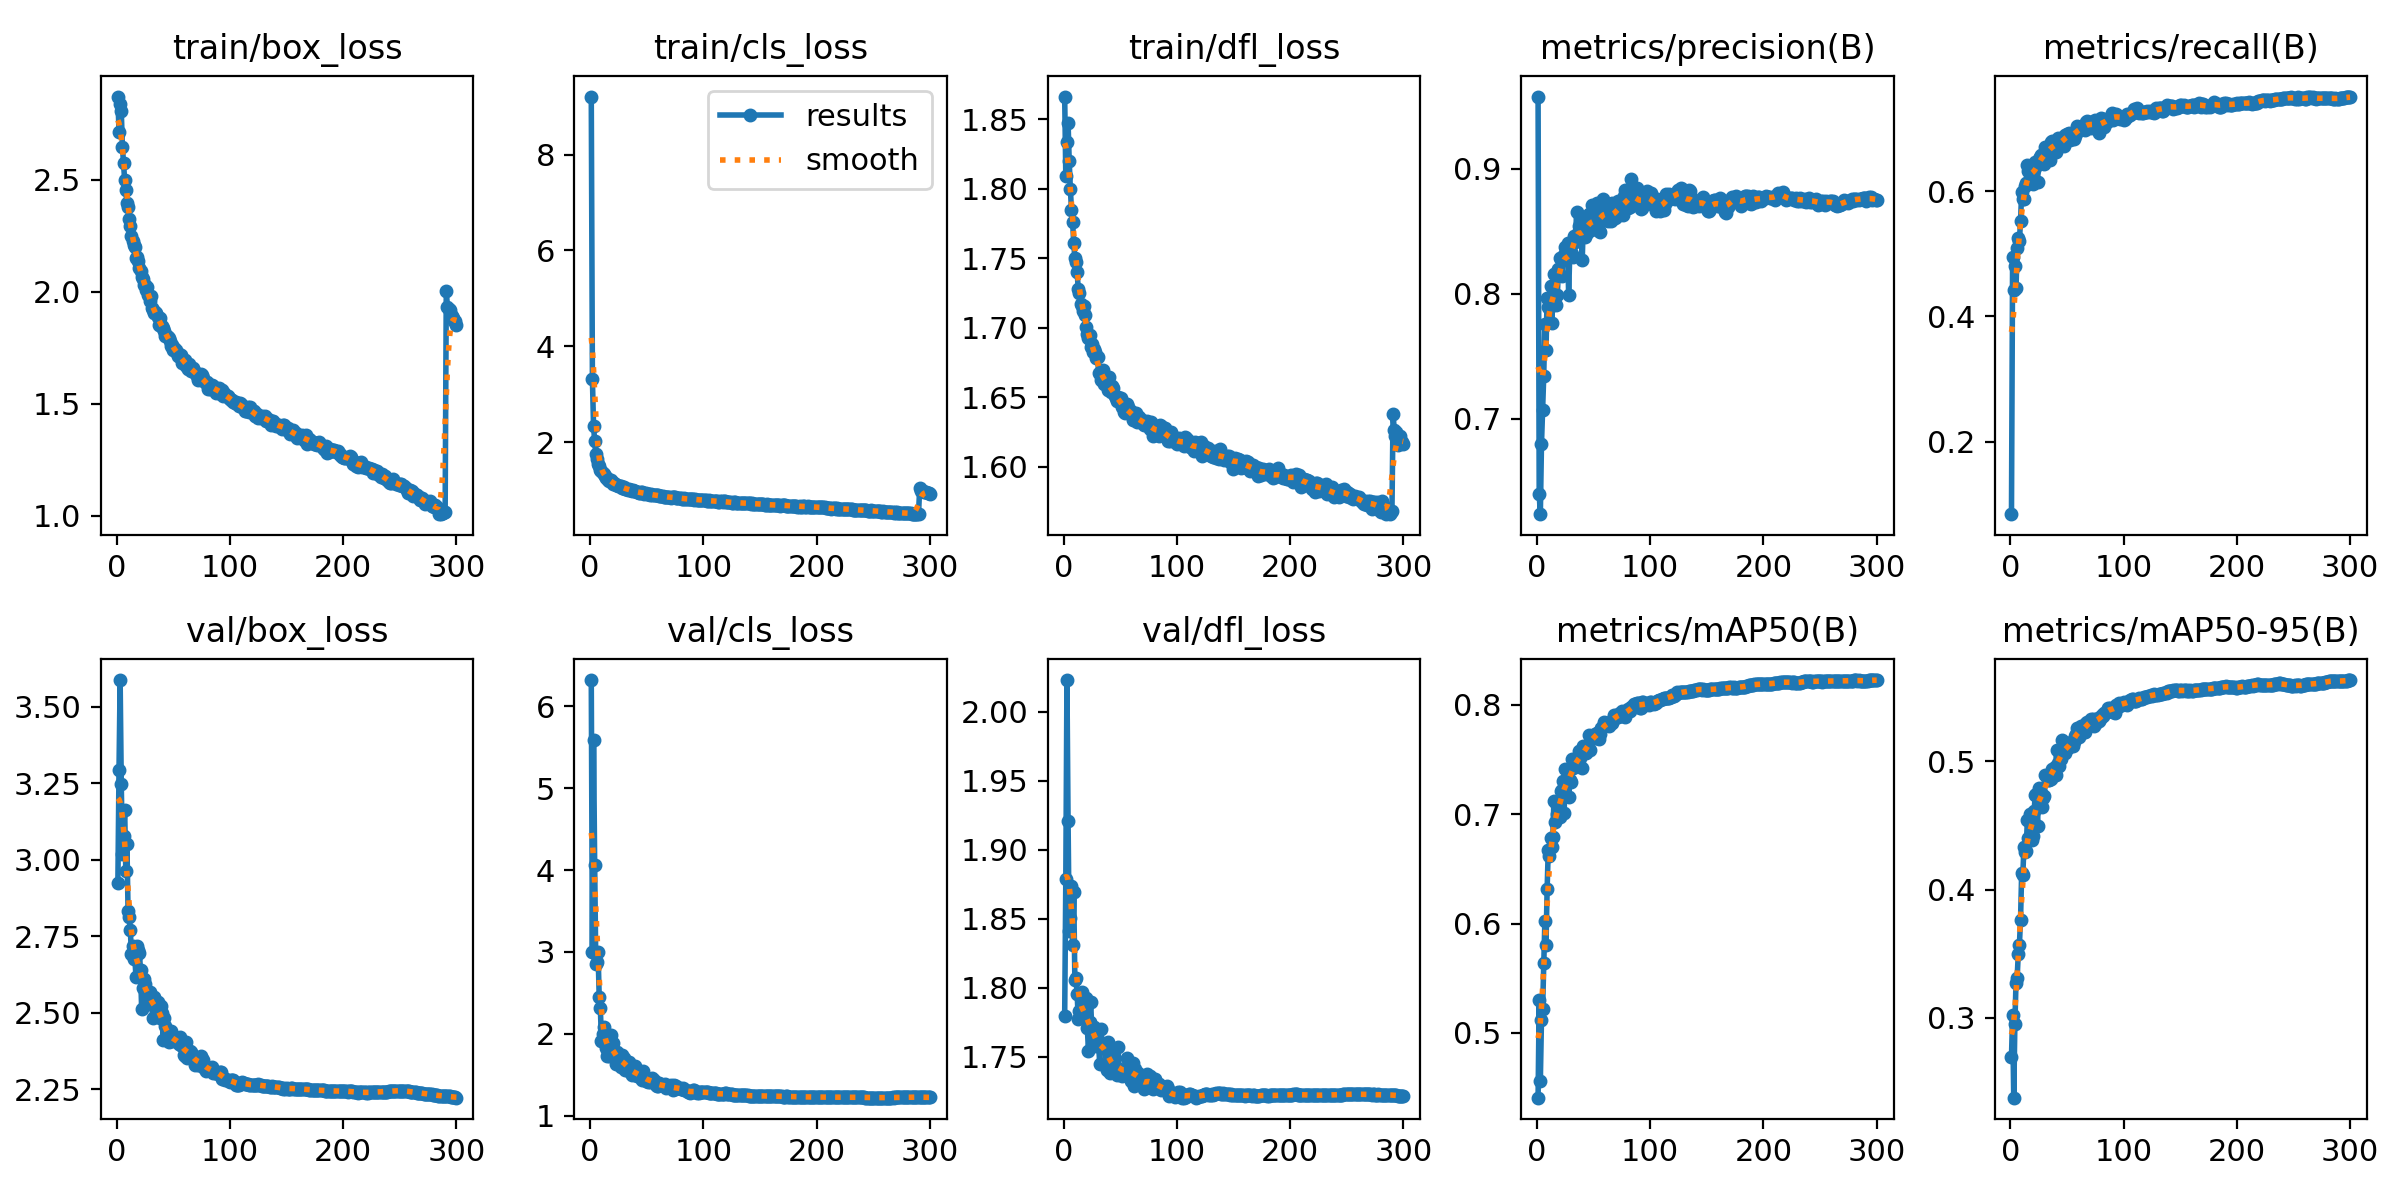

In [19]:
Image(filename=f'{HOME}/runs/detect/tsd_model_8/results.png', width=800)

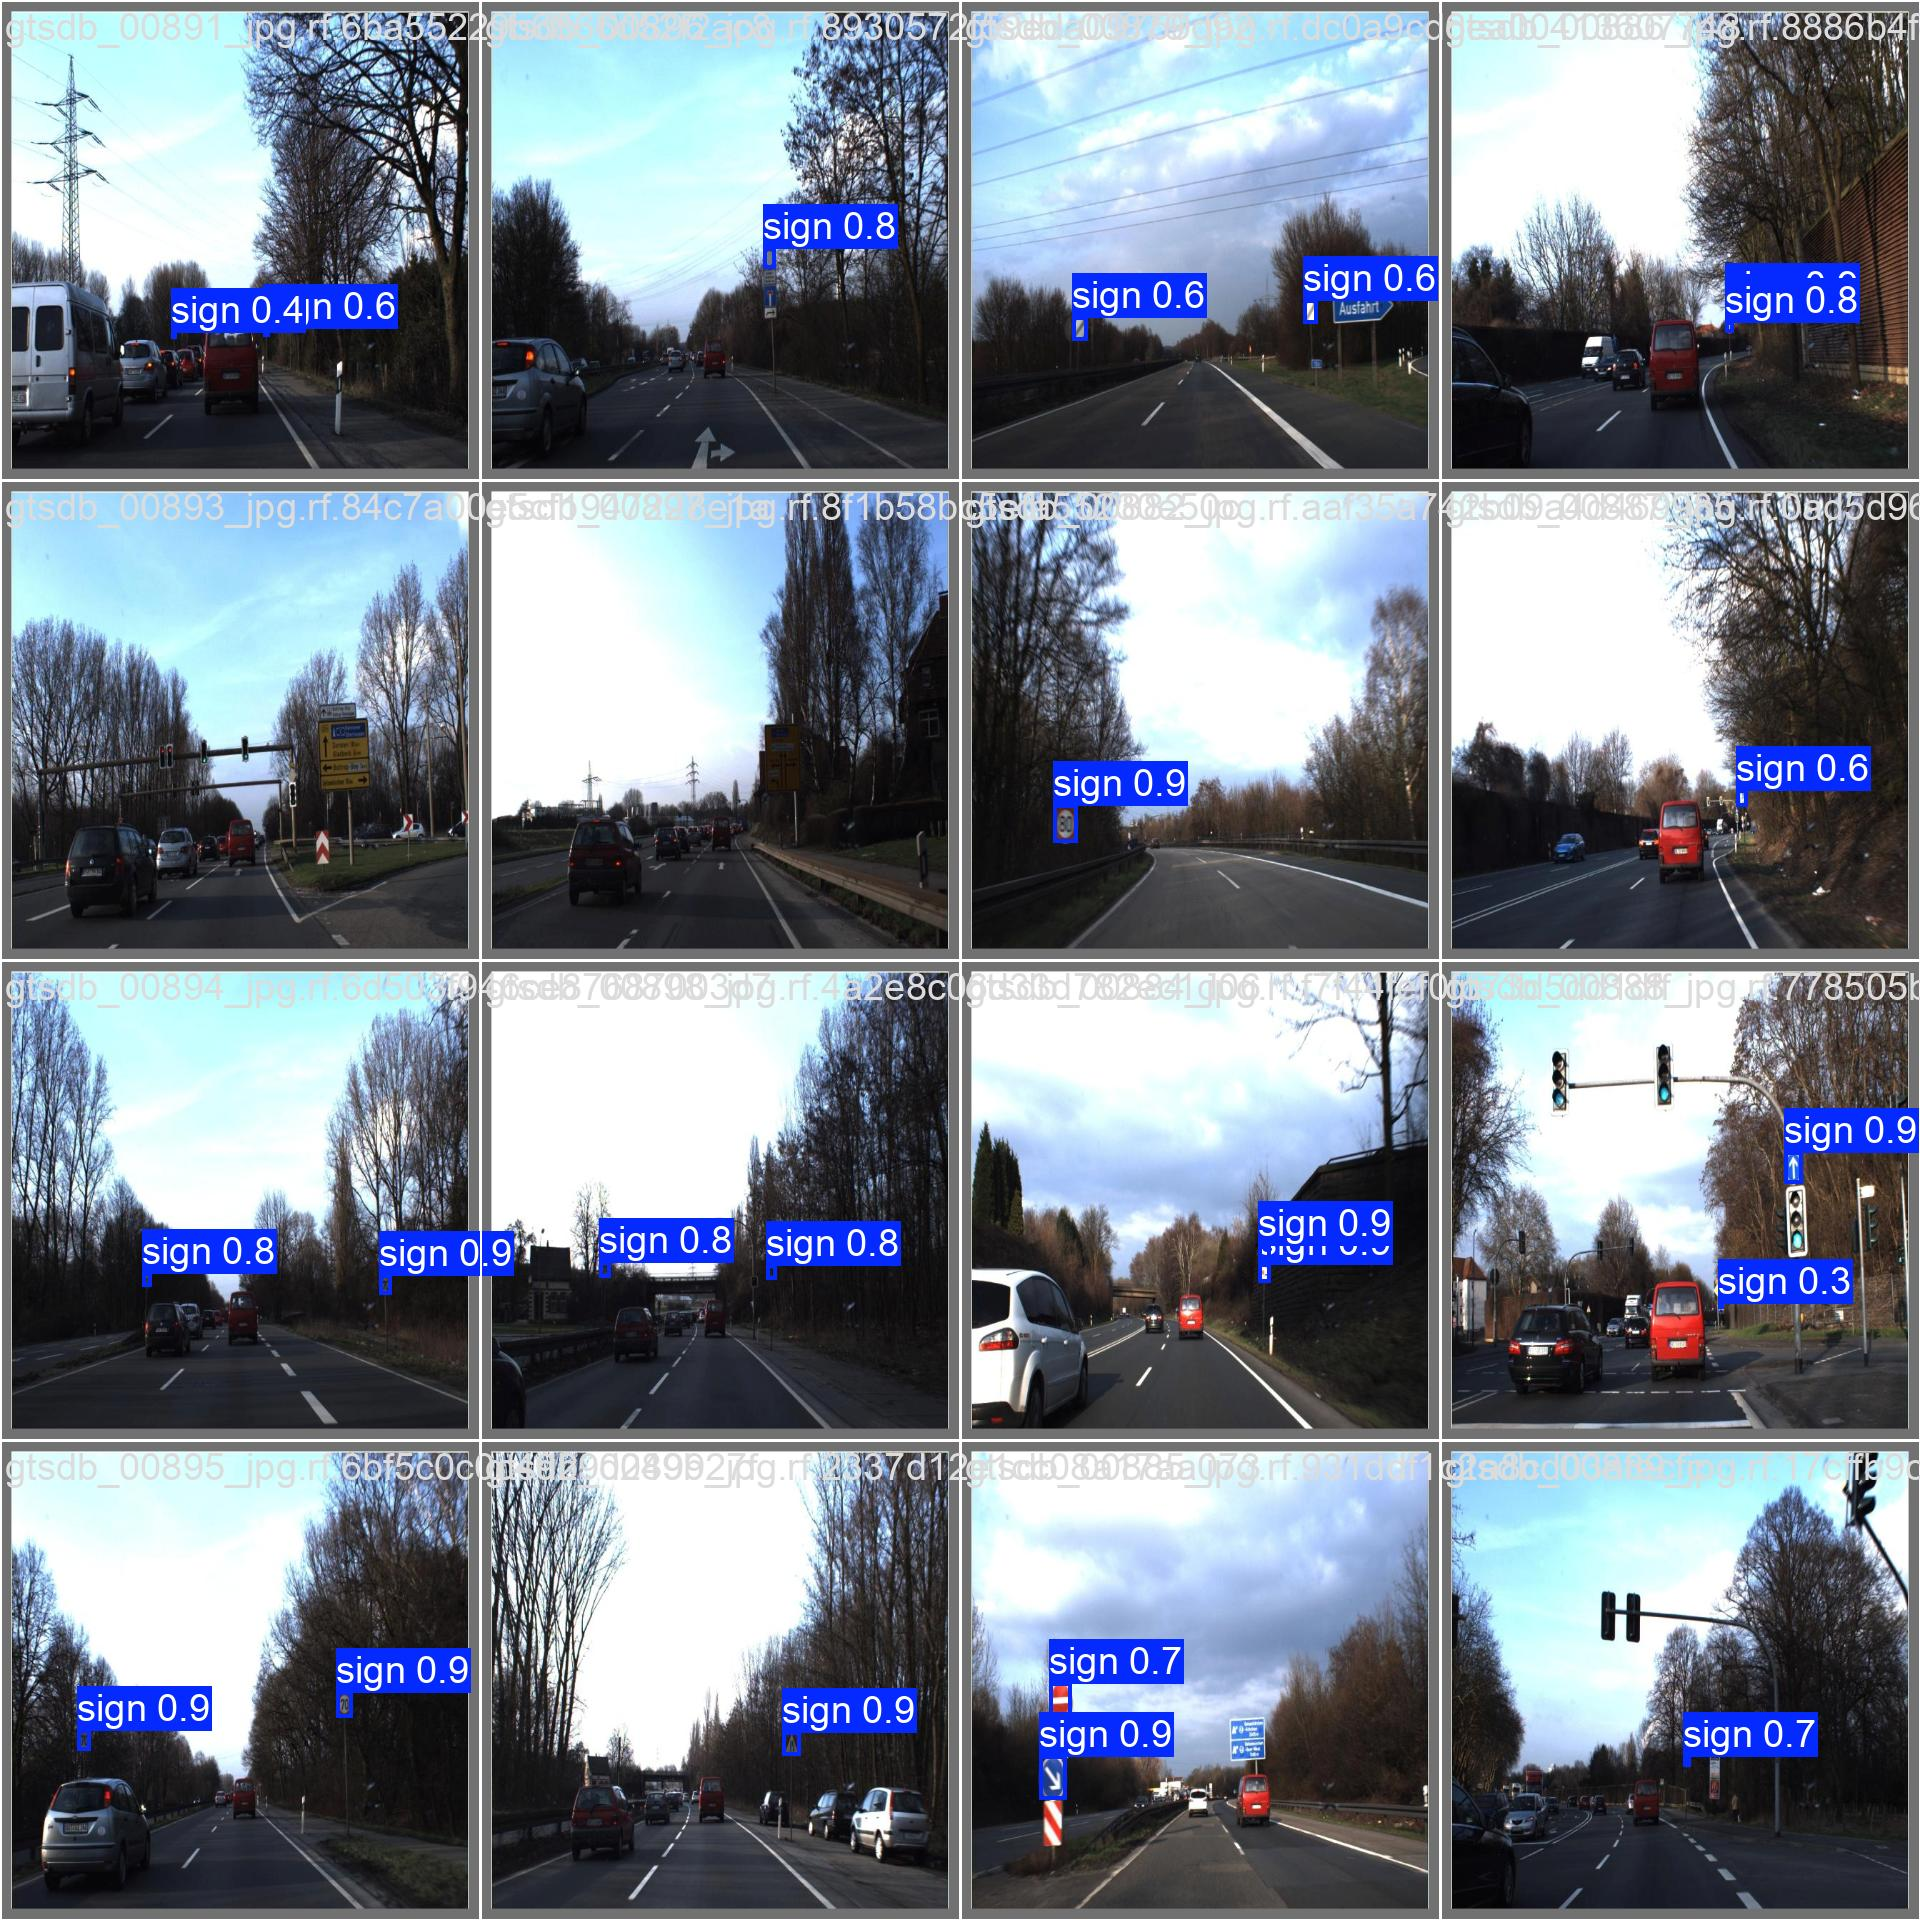

In [20]:
Image(filename=f'{HOME}/runs/detect/tsd_model_8/val_batch0_pred.jpg', width=800)

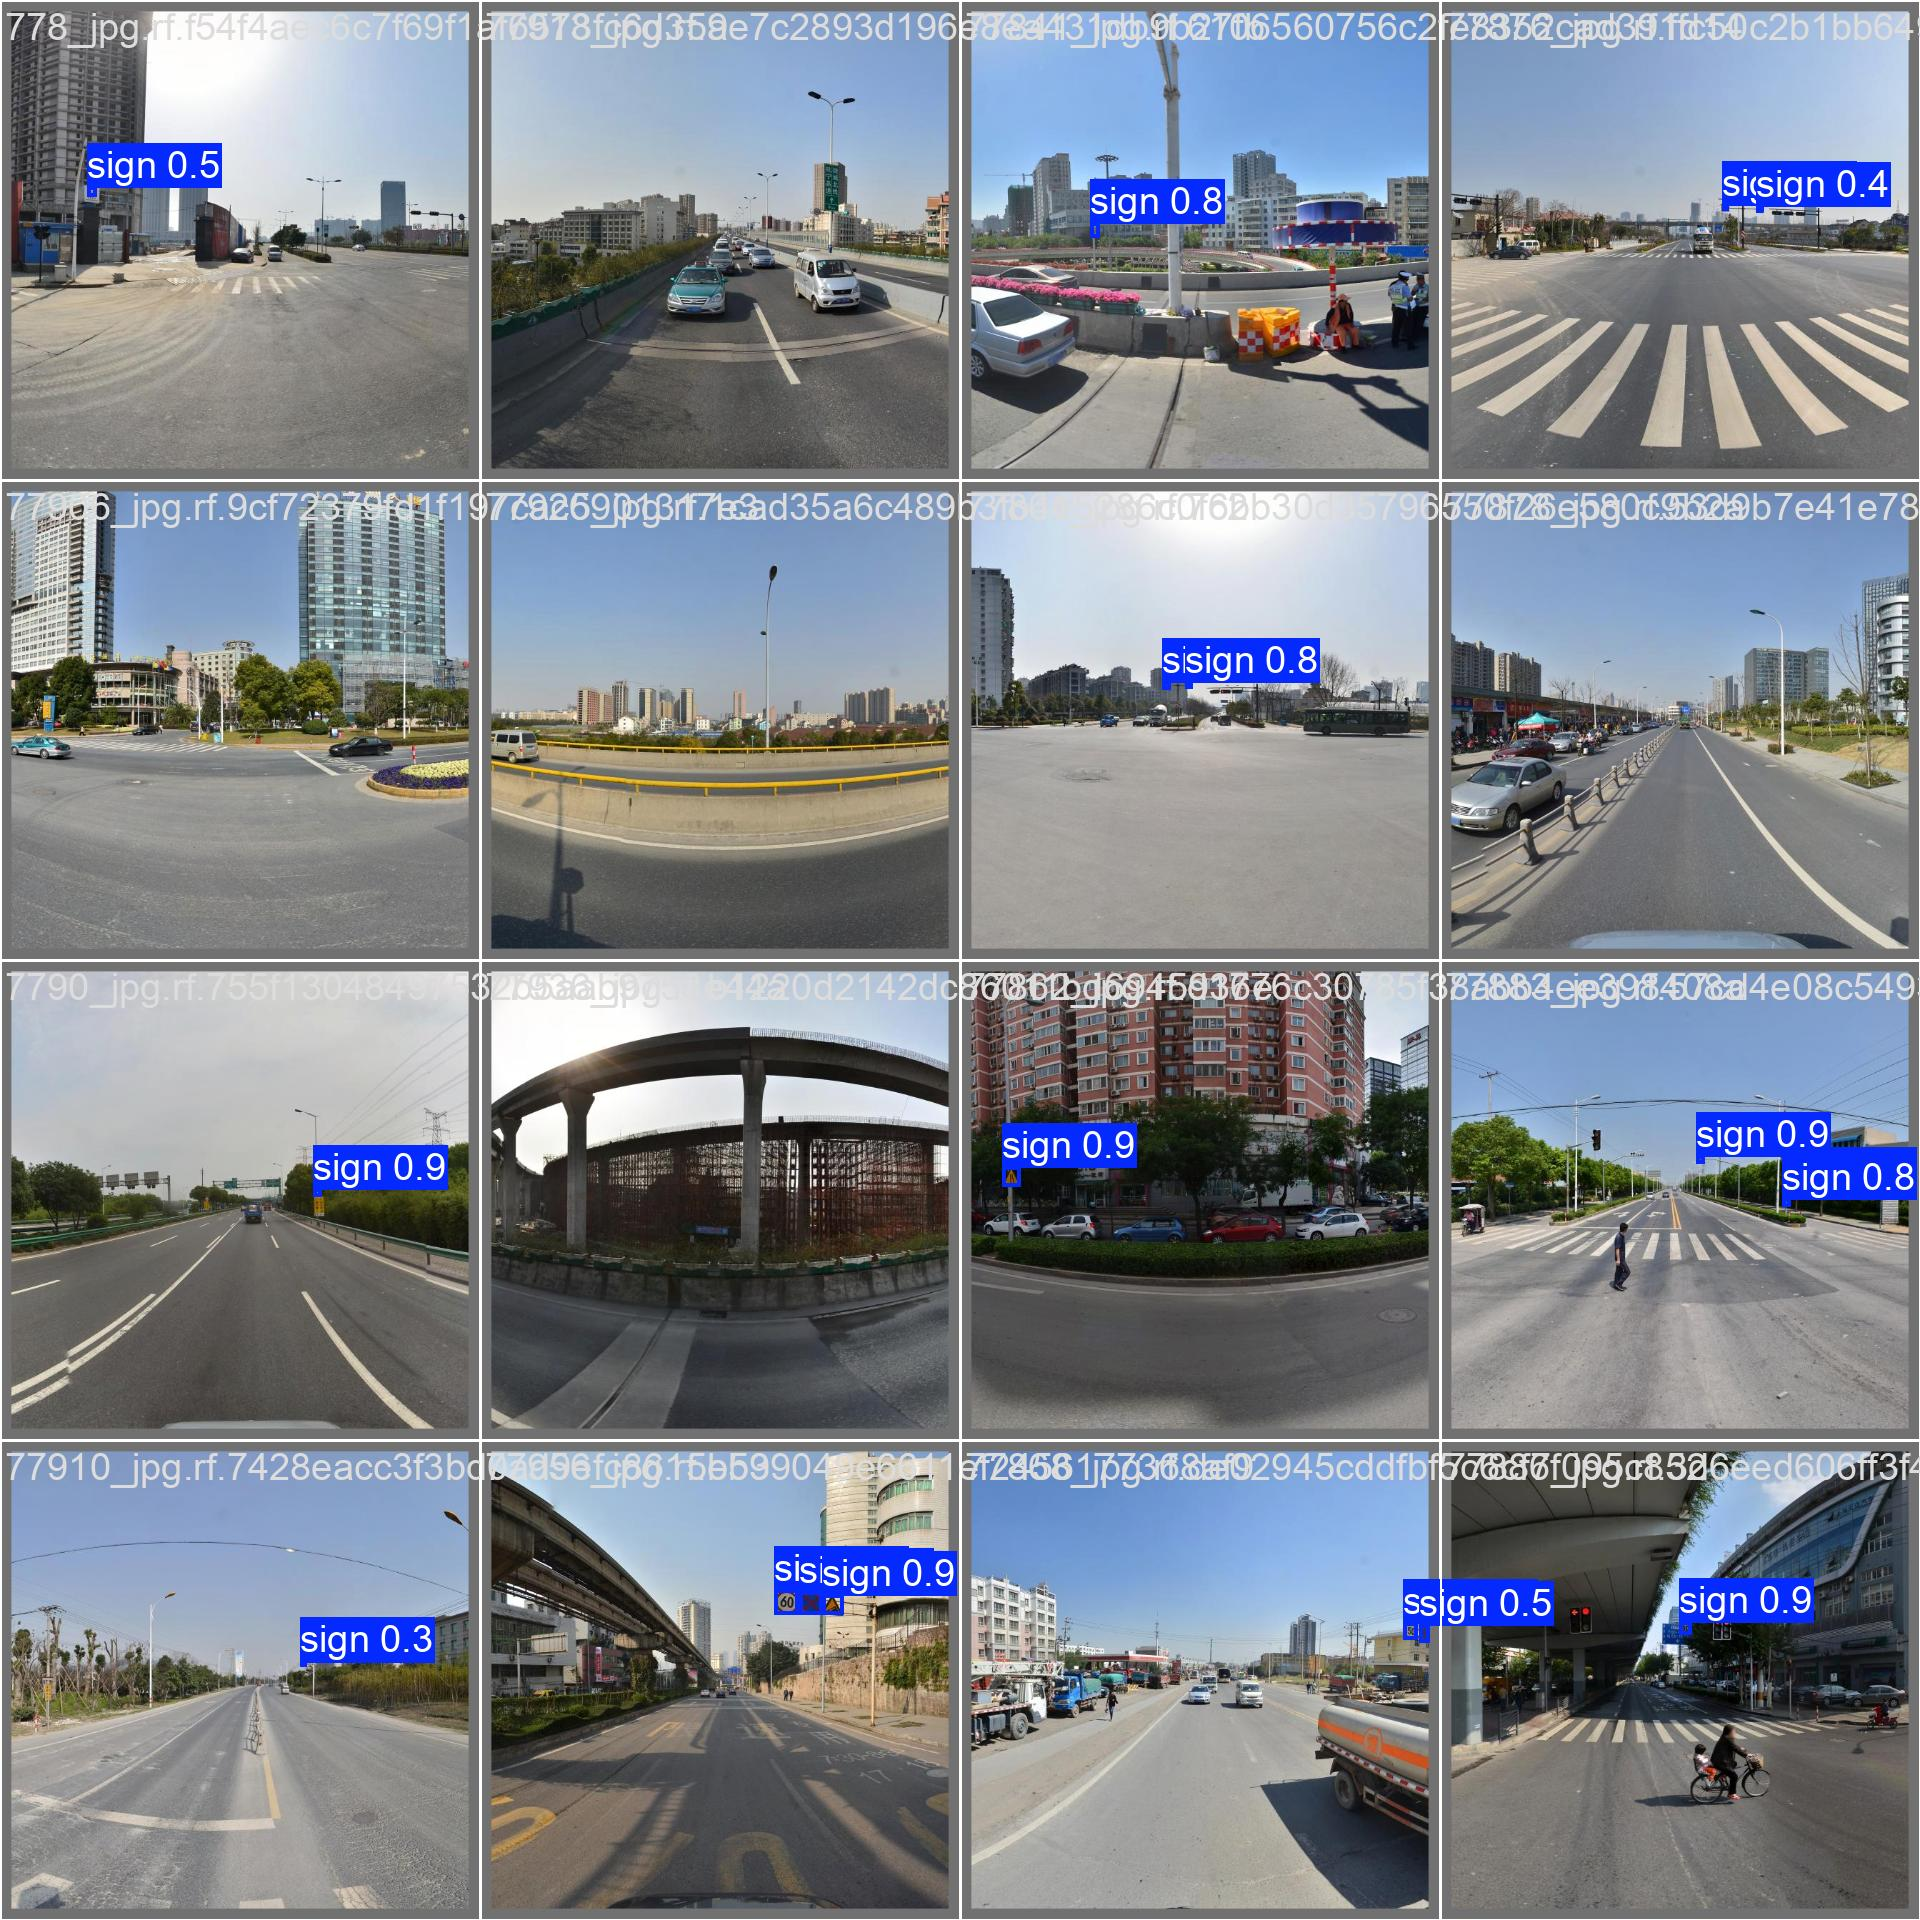

In [22]:
Image(filename=f'{HOME}/runs/detect/tsd_model_8/val_batch1_pred.jpg', width=800)

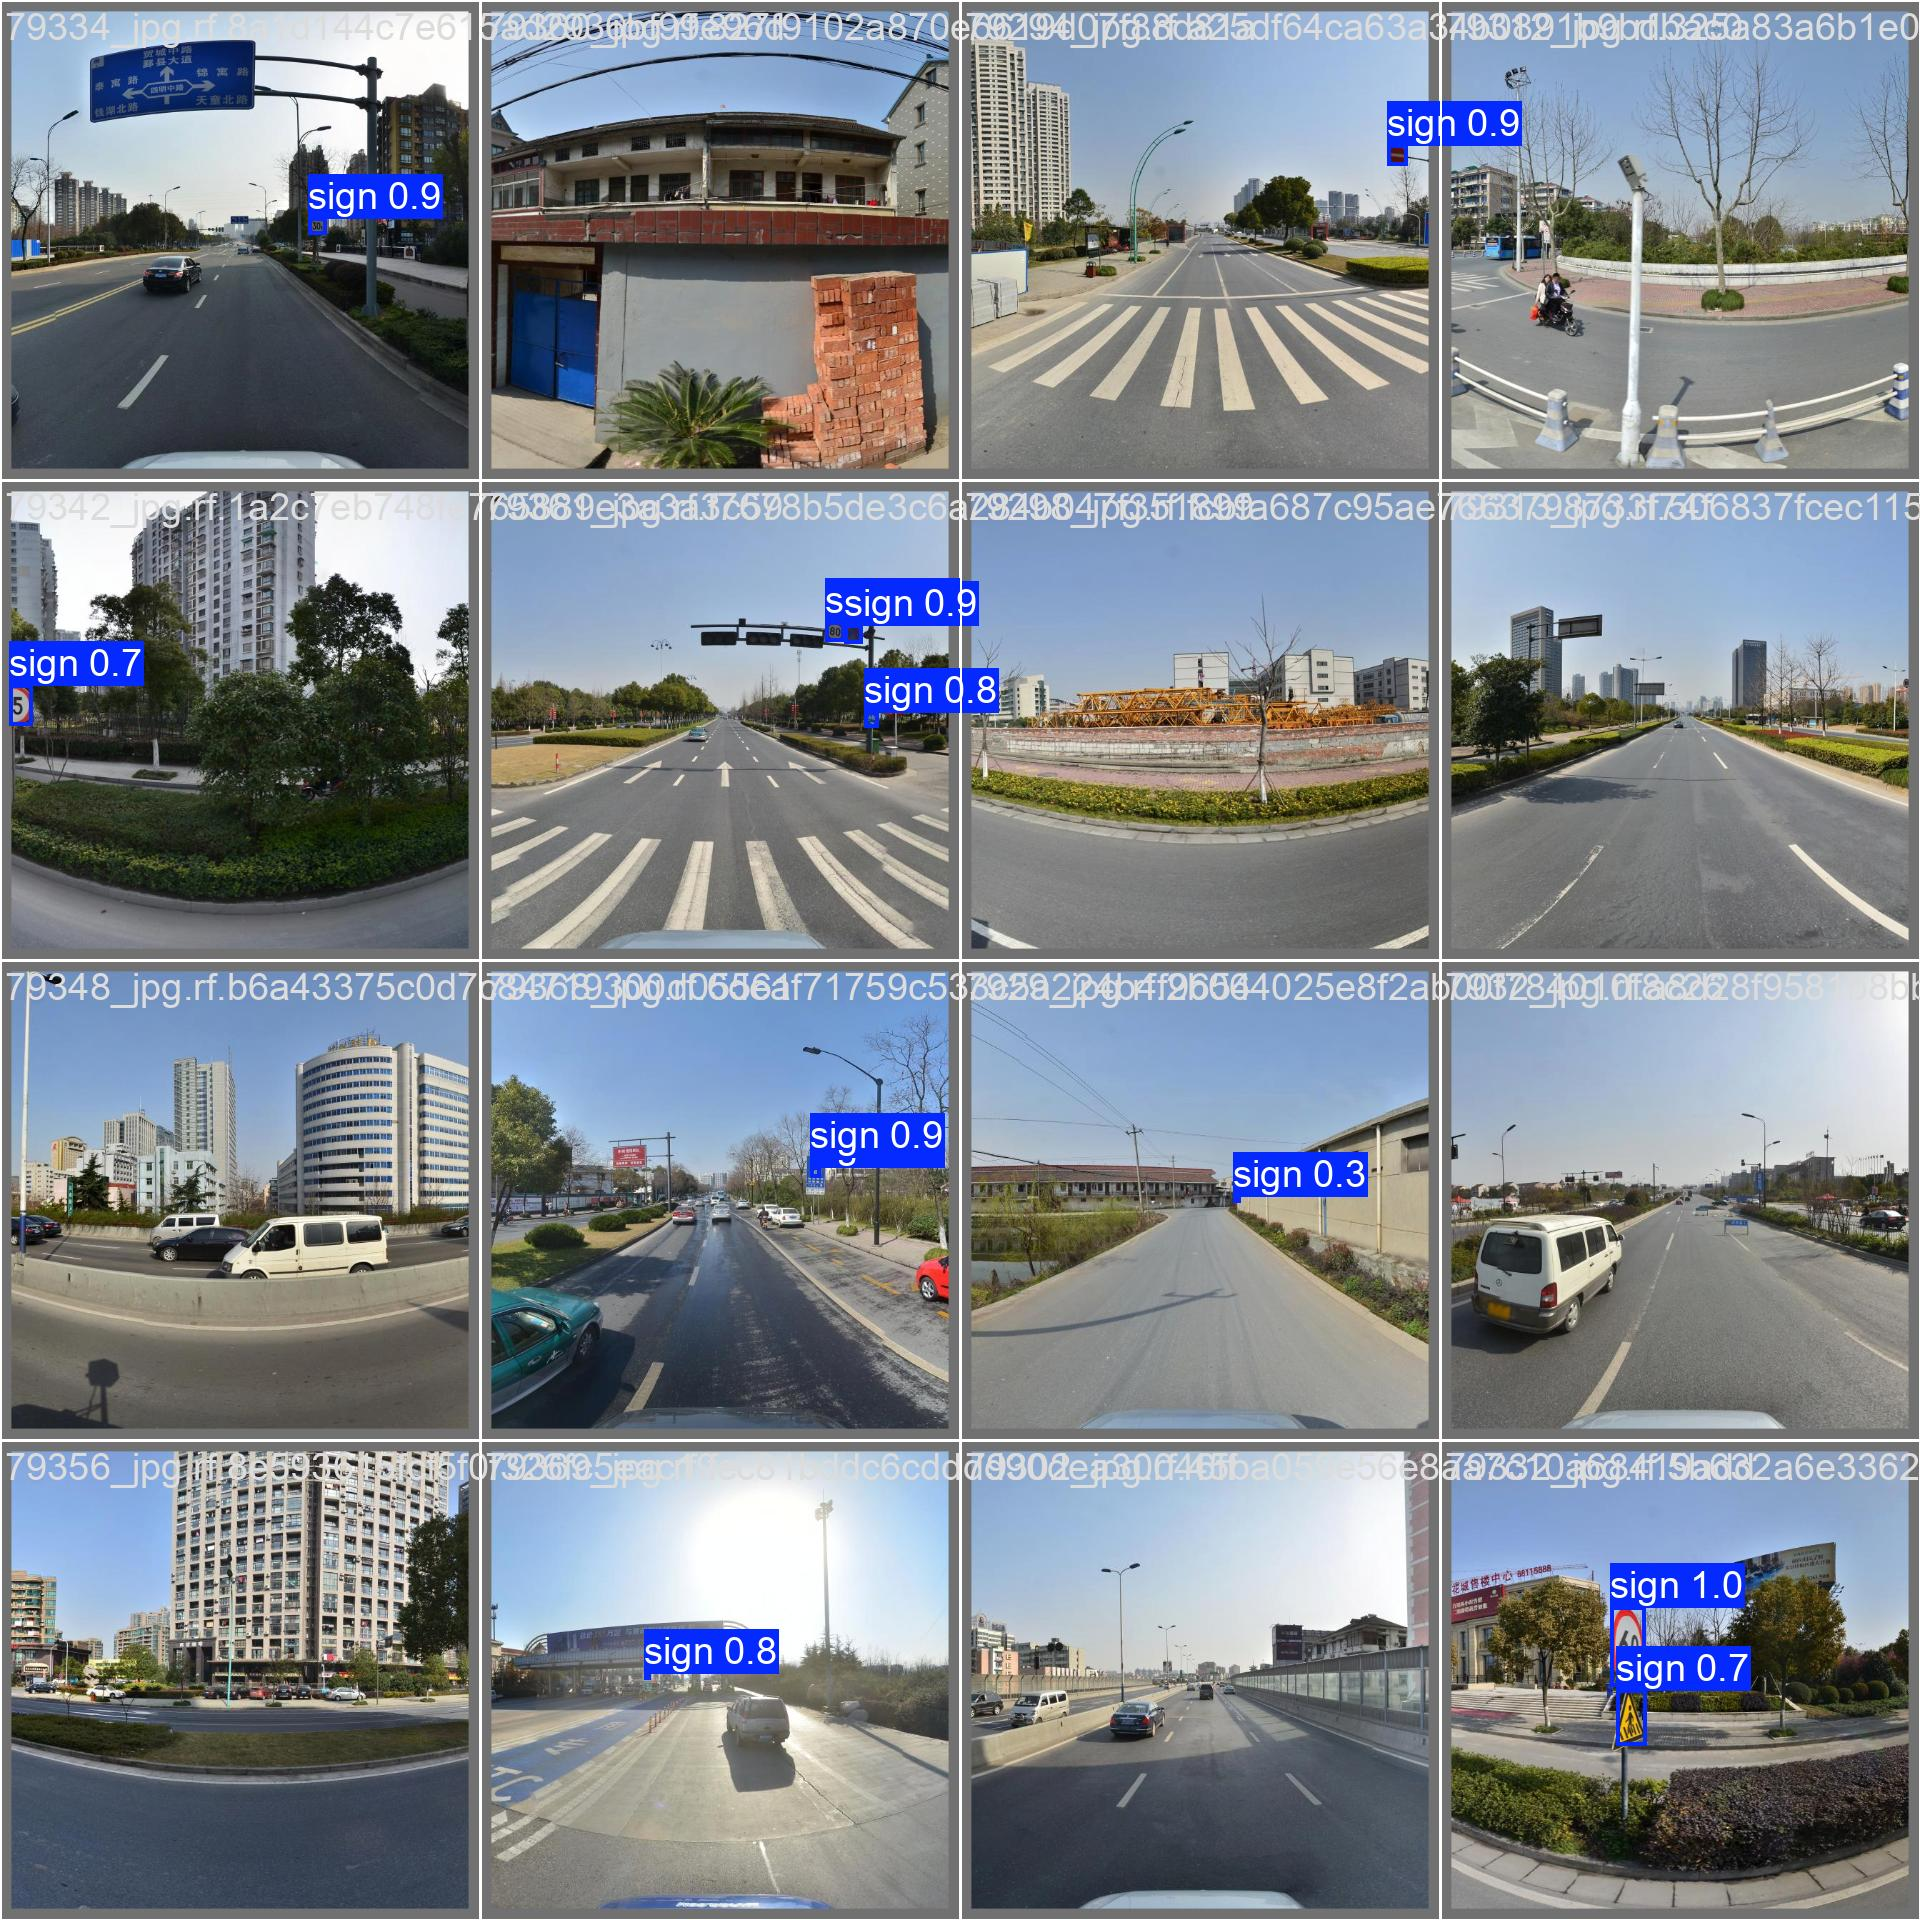

In [21]:
Image(filename=f'{HOME}/runs/detect/tsd_model_8/val_batch2_pred.jpg', width=800)

### Inference with the Custom Trained Model

In [13]:
!yolo task=detect mode=predict \
model={HOME}/runs/detect/tsd_model_8/weights/best.pt \
conf=0.25 source={dataset.location}/test/images save=True

Ultralytics YOLOv8.2.84 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
YOLOv10n summary (fused): 285 layers, 2,694,806 parameters, 0 gradients, 8.2 GFLOPs

image 1/1000 /content/Traffic-Sign-Detection-16/test/images/81644_jpg.rf.95ba65c8178456f6761b864a553f6d48.jpg: 640x640 (no detections), 15.4ms
image 2/1000 /content/Traffic-Sign-Detection-16/test/images/81695_jpg.rf.8f1d8fd53e5722da8143d77d837781c7.jpg: 640x640 (no detections), 11.2ms
image 3/1000 /content/Traffic-Sign-Detection-16/test/images/8169_jpg.rf.2c72b28cc67592dd0e38c00e473d4c2d.jpg: 640x640 9 signs, 11.2ms
image 4/1000 /content/Traffic-Sign-Detection-16/test/images/81730_jpg.rf.d3c1c00b459b55b40b0be2bbbfed04bb.jpg: 640x640 (no detections), 11.6ms
image 5/1000 /content/Traffic-Sign-Detection-16/test/images/81731_jpg.rf.ff6ffa04143b1109dbcc4ada3e9e26f9.jpg: 640x640 10 signs, 11.0ms
image 6/1000 /content/Traffic-Sign-Detection-16/test/images/81733_jpg.rf.e71227940952f5ba05cf19b54f964b80.jpg: 640x6

**NOTE:** Let's take a look at few results.

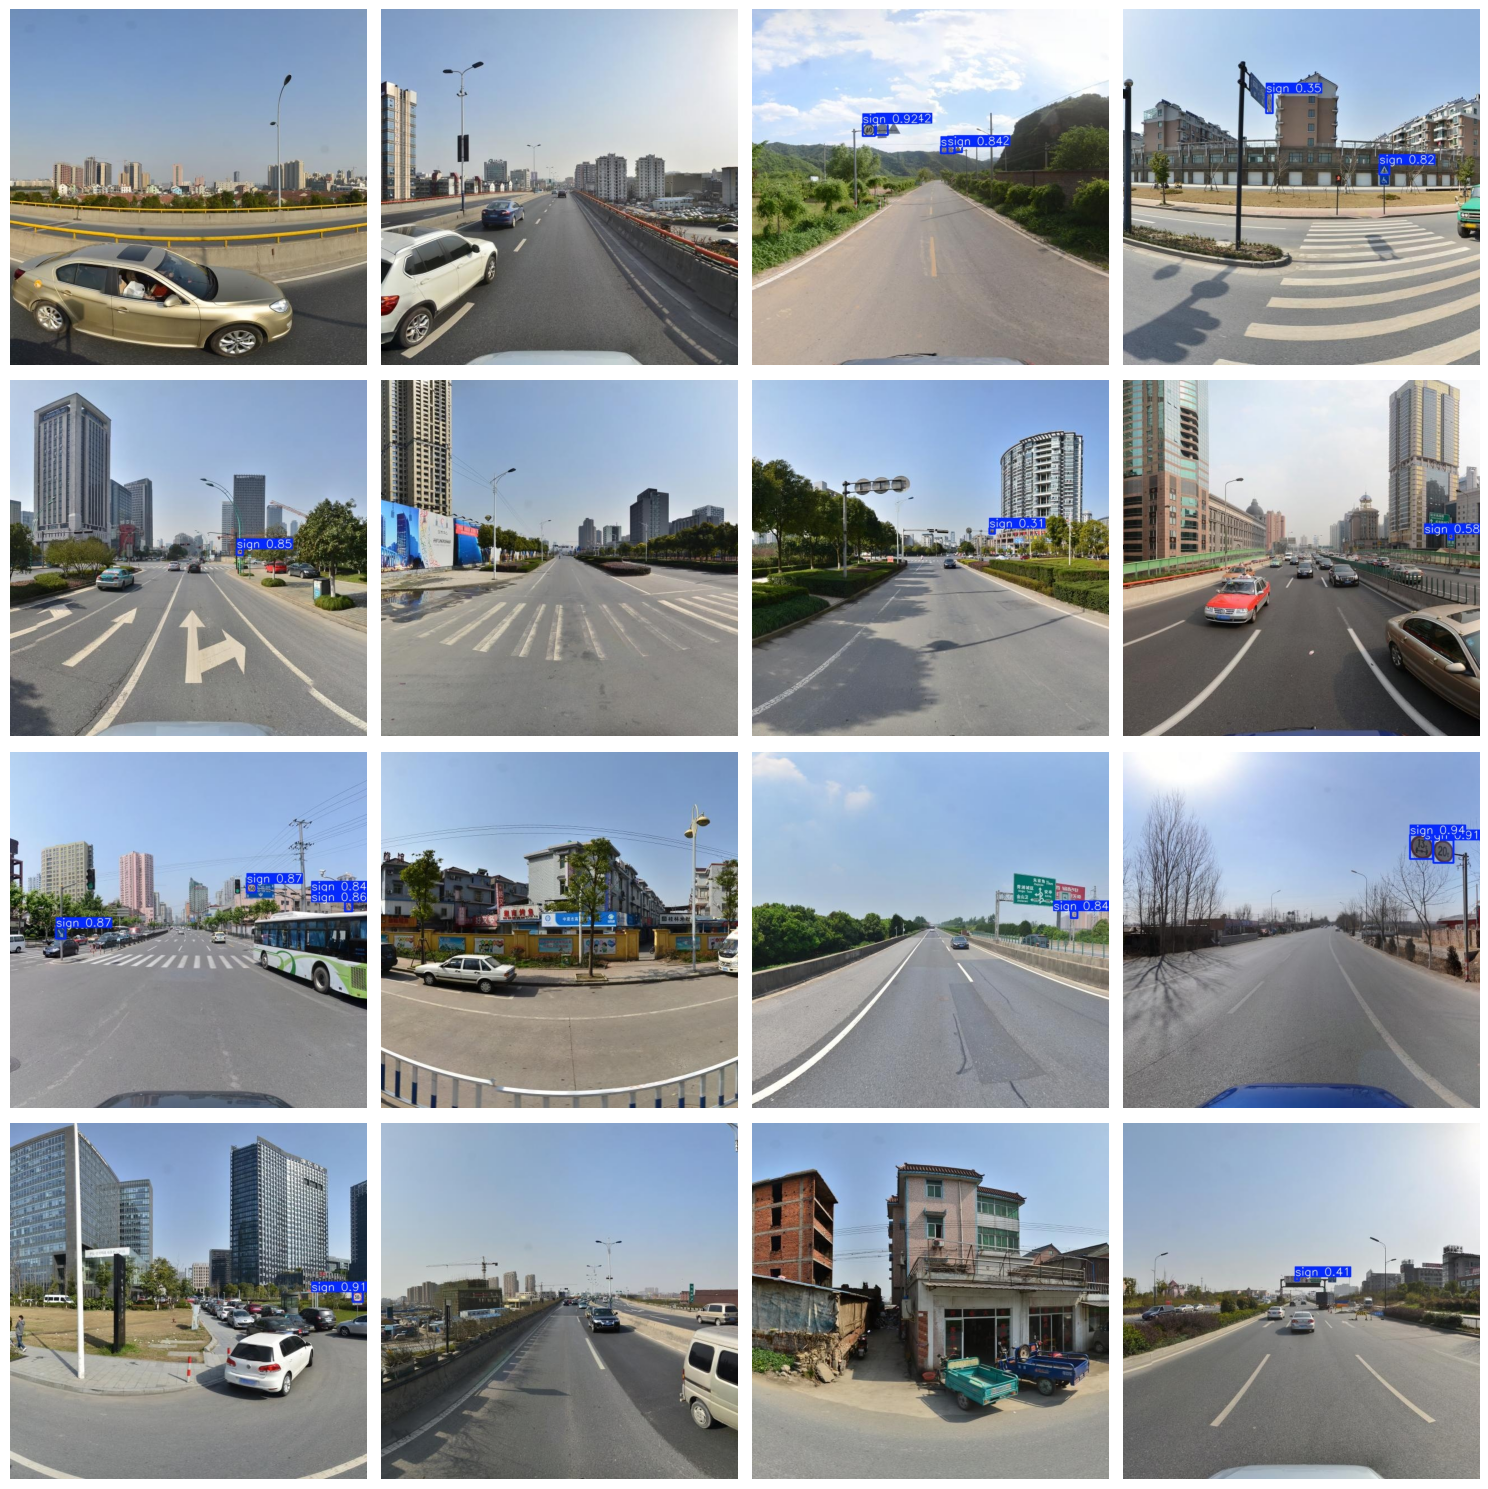

In [17]:
image_paths = glob.glob(f'{HOME}/runs/detect/predict/*.jpg')[:16]
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

for ax, img_path in zip(axes, image_paths):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Export Model

### Downloading Calibration Dataset from Roboflow

In [23]:
rf = Roboflow(api_key="S1UXwOO14zABClWuufoa")
project = rf.workspace("my-workspace-ozcmx").project("traffic-sign-detection-vnb4u")
version = project.version(17)
calibration_dataset = version.download("yolov9")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Sign-Detection-17 in yolov9:: 100%|██████████| 40012/40012 [00:05<00:00, 6773.80it/s] 


### Convert Model to TFLite with INT8 Quantization

In [25]:
model = YOLO('runs/detect/tsd_model_8/weights/best.pt')
model.export(format='tflite', int8=True, data=f'{calibration_dataset.location}/data.yaml')

Ultralytics YOLOv8.2.84 🚀 Python-3.10.12 torch-2.4.0+cu121 CPU (Intel Xeon 2.20GHz)
YOLOv10n summary (fused): 285 layers, 2,694,806 parameters, 0 gradients, 8.2 GFLOPs

PyTorch: starting from 'runs/detect/tsd_model_8/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.5 MB)

TensorFlow SavedModel: starting export with tensorflow 2.17.0...

ONNX: starting export with onnx 1.16.2 opset 19...
ONNX: slimming with onnxslim 0.1.32...
ONNX: export success ✅ 1.7s, saved as 'runs/detect/tsd_model_8/weights/best.onnx' (9.0 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/content/Traffic-Sign-Detection-17/data.yaml'


Scanning /content/Traffic-Sign-Detection-17/valid/labels.cache... 500 images, 193 backgrounds, 0 corrupt: 100%|██████████| 500/500 [00:00<?, ?it/s]


TensorFlow SavedModel: starting TFLite export with onnx2tf 1.22.3...

Automatic generation of each OP name started ========================================
Automatic generation of each OP name complete!

Model loaded ========================================================================

Model conversion started ============================================================
saved_model output started ==========================================================
saved_model output complete!
Float32 tflite output complete!
Float16 tflite output complete!
Dynamic Range Quantization tflite output complete!
Input signature information for quantization
signature_name: serving_default
input_name.0: images shape: (1, 640, 640, 3) dtype: <dtype: 'float32'>
INT8 Quantization tflite output complete!
Full INT8 Quantization tflite output complete!
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/onnx2tf/onnx2tf.py", line 1566, in convert
    tflite_model = converter.c

'runs/detect/tsd_model_8/weights/best_saved_model/best_int8.tflite'

## Zipping Files from the Training Run

In [26]:
import os
os.chdir("/content/runs")

In [27]:
import zipfile

def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(folder_path):
            for file in files:
                zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), folder_path))

# Define paths
folder_path = "/content/runs"
output_path = "/content/tsd_8.zip"

# Zip the folder
zip_folder(folder_path, output_path)